In [13]:
import numpy as np
import pandas as pd
import os, sys, glob, shutil 
from config import *
from plotting_functions import *
import analysis_helpers as helper
sys.path.insert(0,'../..')
%load_ext autoreload
%autoreload 2
%matplotlib inline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import inspect
from scipy.spatial.distance import pdist, cdist, squareform
from scipy.stats import zscore, wasserstein_distance, ttest_1samp, ttest_rel, ttest_ind, sem,f_oneway, spearmanr, pearsonr
from sklearn.decomposition import PCA 
import matplotlib as mpl
from TPHATE.tphate import tphate
import scprep
import nibabel as nib
from nilearn.maskers import NiftiMasker
from nibabel import Nifti1Image
from nilearn import plotting,image  
import matplotlib 
matplotlib.rcParams['pdf.fonttype'] = 42 
matplotlib.rcParams["pdf.use14corefonts"] = True
sns.set_context(context_params)
plt.rcParams.update({
    'font.size': 10,           # Default text size
    'axes.titlesize': 12,      # Axes title
    'axes.labelsize': 12,      # Axes labels
    'xtick.labelsize': 8,     # X tick labels
    'ytick.labelsize': 8,     # Y tick labels
    'legend.fontsize': 11,     # Legend
    'figure.titlesize': 14     # Figure title
})
from scipy.ndimage import zoom


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Embedding scatterplots shown in Figure 1B and S2A,B

In [8]:
def transform_values_to_2d_colormap(values0, values1, C0, C1, C2, C3, cmap_resolution=200, plot=True):
    im = np.array([[C0, C1], [C2, C3]])
    zoomed = zoom(im,(cmap_resolution/2,cmap_resolution/2,1), order=1)
    if plot:
        plt.subplot(121)
        plt.imshow(im,interpolation='nearest')
        plt.subplot(122)
        plt.imshow(zoomed,interpolation='nearest')
        plt.savefig('plots/colorbar.pdf',transparent=True)
    
    # now map values
    minn = np.min([np.min(values0), np.min(values1)])
    maxx = np.max([np.max(values0), np.max(values1)])
    
    m, b = np.polyfit([minn, maxx], [0, cmap_resolution], 1)
    transform = lambda x : x * m + b 
    clip2range_min = lambda V : np.where(V >= 0, V, 0)
    clip2range_max = lambda V : np.where(V < cmap_resolution, V, cmap_resolution-1)
    transform_and_clip = lambda values : clip2range_max(clip2range_min(transform(values)))
    v0_scaled = transform_and_clip(values0).astype(int)
    v1_scaled = transform_and_clip(values1).astype(int)
    final_colors = [zoomed[v0,v1] for v0,v1 in zip(v0_scaled, v1_scaled)]
    return np.array(final_colors)
    
def rgb_to_hex(RGB):
    r, g, b = RGB[0],RGB[1],RGB[2]
    return '#{:02x}{:02x}{:02x}'.format(r, g, b)
    
def create_scatterplot_2dim_colors(tphate_embedding, xlabels, zlabels, colors_4, size=10, cmap_resolution=200, plot=False, outname=None,twoDScatter=False):
    C0, C1, C2, C3 = colors_4
    final_colormap = transform_values_to_2d_colormap(xlabels, zlabels, C0, C1, C2, C3, cmap_resolution=cmap_resolution, plot=plot)
    hex_colors = [rgb_to_hex(c) for c in final_colormap]
    rgb_colors = [rgb2range(c) for c in final_colormap]
    T1 = tphate_embedding[:len(xlabels)]
    if plot == False:
        return T1, hex_colors
    if twoDScatter:
        scprep.plot.scatter2d(T1, c=rgb_colors, ticks=False, alpha=1,s=size,figsize=(3,3),filename=outname,legend=False  )
    else:
        scprep.plot.scatter3d(T1, c=rgb_colors, ticks=False, alpha=1,s=size,figsize=(3,3),filename=outname,legend=False )
    if outname != None:
        plt.close()
    return final_colormap,hex_colors

def run_connected_3D_scatterplot(tphate_embedding, labels1, labels2, colors_4, size=10, cmap_resolution=200, outname=None):
    C0, C1, C2, C3 = colors_4
    final_colormap = transform_values_to_2d_colormap(labels1,labels2, C0, C1, C2, C3, cmap_resolution=cmap_resolution, plot=False)
    hex_colors = [rgb_to_hex(c) for c in final_colormap]
    T1 = tphate_embedding[:len(labels1)]
    rgb_colors = [rgb2range(c) for c in final_colormap]
    plot_3d_scatter_with_lines(T1, rgb_colors, size, outname)
    
def run_connected_2D_scatterplot(tphate_embedding, labels1, labels2, colors_4, size=10, cmap_resolution=200, outname=None):
    C0, C1, C2, C3 = colors_4
    final_colormap = transform_values_to_2d_colormap(labels1,labels2, C0, C1, C2, C3, cmap_resolution=cmap_resolution, plot=False)
    hex_colors = [rgb_to_hex(c) for c in final_colormap]
    T1 = tphate_embedding[:len(labels1)]
    rgb_colors = [rgb2range(c) for c in final_colormap]
    plot_2d_scatter_with_lines(T1, rgb_colors, size, outname)
    
def plot_2d_scatter_with_lines(data, c, size=10,outname=None):
    fig,ax = plt.subplots(1,1,figsize=(4,4))
    x,y=data[:,0],data[:,1]
    # Scatter plot
    ax.scatter(x, y, c=c, marker='o', s=size, zorder=2, alpha=1)
    
    # Connect points with lines
    ax.plot(x, y, c='gray', zorder=1,alpha=0.4)
    # Turn off ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Turn off grid
    ax.grid(False)
    
    # Labels
    ax.set_xlabel('T-PHATE 0')
    ax.set_ylabel('T-PHATE 1')
    if outname:
        plt.savefig(outname, transparent=True,bbox_inches = "tight")
        plt.close()
    else:
        plt.show()

def plot_3d_scatter_with_lines(data, c, size=10,outname=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x,y,z=data[:,0],data[:,1],data[:,2]
    # Scatter plot
    ax.scatter(x, y, z, c=c, marker='o', s=size, zorder=2, alpha=1)
    
    # Connect points with lines
    ax.plot(x, y, z, c='gray', zorder=1,alpha=0.4)
    # Turn off ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    
    # Turn off grid
    ax.grid(False)
    
    # Labels
    ax.set_xlabel('T-PHATE 0')
    ax.set_ylabel('T-PHATE 1')
    ax.set_zlabel('T-PHATE 2')
    if outname:
        plt.savefig(outname, transparent=True,bbox_inches = "tight")
        plt.close()
    else:
        plt.show()

def rgb2range(RGB):
    r, g, b = RGB[0],RGB[1],RGB[2]
    return (r/256, g/256, b/256)

def average_groups(X, V):
    N = len(X)
    group_size = N // V
    averaged_values = np.array([np.mean(X[i*group_size:(i+1)*group_size]) for i in range(V)]) 
    return averaged_values

In [9]:
def load_joystick_data_for_vis(subject_id, run, shiftby=2, trials=[]):
    infn = f'{DATA_PATH}/{subject_id}/ses_01/func/{subject_id}_task-RT_run-{run:02d}_bold_preproc_v2_native.nii.gz'
    outfn= f'{SCRATCH_PATH}//{subject_id}_run_{run:02d}_bold_preproc_v2_native_navigation_mask.npy'
    mask = nib.load(f'{DATA_PATH}/{subject_id}/reference/mask.nii.gz').get_fdata()
    nii_data=nib.load(infn).get_fdata()
    ds = nii_data[mask==1].T
    ds=zscore(ds,axis=0)
    np.save(outfn,ds)
    print(f"saved to {outfn}")
    trials_shifted, xshifted, zshifted = load_joystick_location_labels(subject_id, 'ses_01', run, ds.shape[0], shiftby)
    print(ds.shape, len(trials_shifted), len(xshifted))
    if ds.shape[0]!=len(trials_shifted):
        ds=ds[:len(trials_shifted)]
    return ds, trials_shifted, xshifted, zshifted

def load_joystick_location_labels(subject_id, session_id, run, nTRs_data, shiftby):
    reg_df = pd.read_csv(f'{DATA_PATH}/{subject_id}/{session_id}/behav/run_{run:03d}_events_master_revised_v2.csv', index_col=0)
    trial_OnOff = reg_df['isTrial'].values
    trial_numbers = reg_df['trial_number'].values
    xvalues = reg_df['x_coord'].values
    zvalues = reg_df['z_coord'].values
    trial_numbers_shifted, toTrim = helper.shift_timing(nTRs_data, trial_numbers, shiftby, start_label=0)
    xvalues_shifted,_ = helper.shift_timing(nTRs_data, xvalues, shiftby, start_label=0)
    zvalues_shifted,_ = helper.shift_timing(nTRs_data, zvalues, shiftby, start_label=0)
    return trial_numbers_shifted, xvalues_shifted, zvalues_shifted



In [10]:
C0 = [256,256,256]
C1 = [255,0,0] # pink
C2 = [154, 204, 213] # teal
C3 = [0,0,0]
COLORS=[C0,C1,C2,C3]
subjects = [5,7,13,24,25]

In [11]:
for subject_id in subjects[4:]:
    subject_id = f'avatarRT_sub_{subject_id:02d}'
    all_data, all_trs, all_x, all_z, all_runs = [], [], [], [], []
    for run in [1,2,3,4]:
        ds, tr, x, z = load_joystick_data_for_vis(subject_id, run, shiftby=2, trials=[])
        all_data.append(ds[tr>=0])
        all_trs.append(tr[tr>=0])
        all_x.append(x[tr>=0])
        all_z.append(z[tr>=0])
        all_runs.append(np.repeat(run,len(ds[tr>=0])))
    all_data=np.nan_to_num(np.concatenate(all_data, axis=0))
    all_x=np.concatenate(all_x)
    all_z=np.concatenate(all_z)
    all_runs=np.concatenate(all_runs)
    all_trs=np.concatenate(all_trs)
    # flatten trial labels
    flattened_trials = helper.flatten_trials(all_trs)
    # embed data
    print(all_data.shape, all_x.shape, flattened_trials.min(), flattened_trials.max())
    embd = tphate.TPHATE(n_components=3, verbose=0, t=7).fit_transform(all_data)
    
    skip=4
    for i in range(0, int(flattened_trials.max()), 2):
        to_include = np.arange(i, i+skip)
        outfn = f'plots/data/{subject_id}_tphate_trials_{i:02d}_selected.png'
        mask = [i for i, j in enumerate(flattened_trials) if j in to_include]
        # do some filtering
        E_FIN = embd[mask] 
        Z_FIN =all_x[mask]
        X_FIN = all_z[mask]
        run_connected_3D_scatterplot(E_FIN, X_FIN, Z_FIN, COLORS, size=10, outname=outfn) #f'plots/{S}_scatterplot_3d_selected.pdf')
    plt.close()


FileNotFoundError: [Errno 2] No such file or directory: '/gpfs/milgram/scratch60/turk-browne/elb77/rtoffline///avatarRT_sub_25_run_01_bold_preproc_v2_native_navigation_mask.npy'

## Included visualizations
avatarRT_sub_05: trials 35-39 (91 samples)<br>
avatarRT_sub_07: trials 64-68 (57 samples)<br> 
avatarRT_sub_13: trials 31-37 (59 samples)<br> 
avatarRT_sub_24: trials 42-48 (67 samples)<br> 
avatarRT_sub_25: trials 71-77 (59 samples)<br> 


In [124]:
subjects_trials = {'avatarRT_sub_05':np.arange(35,39), 'avatarRT_sub_07':np.arange(64,69), 
                   'avatarRT_sub_13':np.arange(31,37), 'avatarRT_sub_24':np.arange(42,48),
                   'avatarRT_sub_25':np.arange(71, 77)}

In [126]:
for subject, trials in subjects_trials.items():
    all_data, all_trs, all_x, all_z, all_runs = [], [], [], [], []
    for run in [1,2,3,4]:
        ds, tr, x, z = load_joystick_data_for_vis(subject, run, shiftby=2, trials=[])
        all_data.append(ds[tr>=0])
        all_trs.append(tr[tr>=0])
        all_x.append(x[tr>=0])
        all_z.append(z[tr>=0])
        all_runs.append(np.repeat(run,len(ds[tr>=0])))
    all_data=np.nan_to_num(np.concatenate(all_data, axis=0))
    all_x=np.concatenate(all_x)
    all_z=np.concatenate(all_z)
    all_runs=np.concatenate(all_runs)
    all_trs=np.concatenate(all_trs)
    # flatten trial labels
    flattened_trials = helper.flatten_trials(all_trs)
    # embed data
    print(all_data.shape, all_x.shape, flattened_trials.min(), flattened_trials.max())
    embd = tphate.TPHATE(n_components=3, verbose=0, t=7).fit_transform(all_data)
    pca_data = PCA(n_components=3).fit_transform(all_data)
    np.save(f'temp_data/{subject}_joystick_data_voxel_space.npy', all_data)
    
    outfn = f'revision_plots/{subject}_tphate_trials_3D_embedding_final.pdf'
    mask = [i for i, j in enumerate(flattened_trials) if j in trials]

    E_FIN = embd[mask] 
    PFIN = pca_data[mask]
    print(E_FIN.shape, PFIN.shape)
    Z_FIN =all_x[mask]
    X_FIN = all_z[mask]
    run_connected_3D_scatterplot(E_FIN, X_FIN, Z_FIN, COLORS, size=10, outname=outfn) 
    run_connected_2D_scatterplot(E_FIN, X_FIN, Z_FIN, COLORS, size=10, outname=outfn.replace('3D','2D')) 
    outfn = outfn.replace('tphate','pca')
    run_connected_3D_scatterplot(PFIN, X_FIN, Z_FIN, COLORS, size=10, outname=outfn) 
    run_connected_2D_scatterplot(PFIN, X_FIN, Z_FIN, COLORS, size=10, outname=outfn.replace('3D','2D')) 
    print(f'done {subject_id}')
    

saved to /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline///avatarRT_sub_05_run_01_bold_preproc_v2_native_navigation_mask.npy
(336, 1408) 336 336
saved to /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline///avatarRT_sub_05_run_02_bold_preproc_v2_native_navigation_mask.npy
(289, 1408) 289 289
saved to /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline///avatarRT_sub_05_run_03_bold_preproc_v2_native_navigation_mask.npy
(274, 1408) 274 274
saved to /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline///avatarRT_sub_05_run_04_bold_preproc_v2_native_navigation_mask.npy
(263, 1408) 263 263
(808, 1408) (808,) 0.0 55.0
(75, 3) (75, 3)
done avatarRT_sub_25
saved to /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline///avatarRT_sub_07_run_01_bold_preproc_v2_native_navigation_mask.npy
(300, 1251) 300 300
saved to /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline///avatarRT_sub_07_run_02_bold_preproc_v2_native_navigation_mask.npy
(298, 1251) 298 298
saved to /gpfs/milgram/scratch60/turk-bro

# Projections and loadings: C_IM, C_WMP, C_OMP 

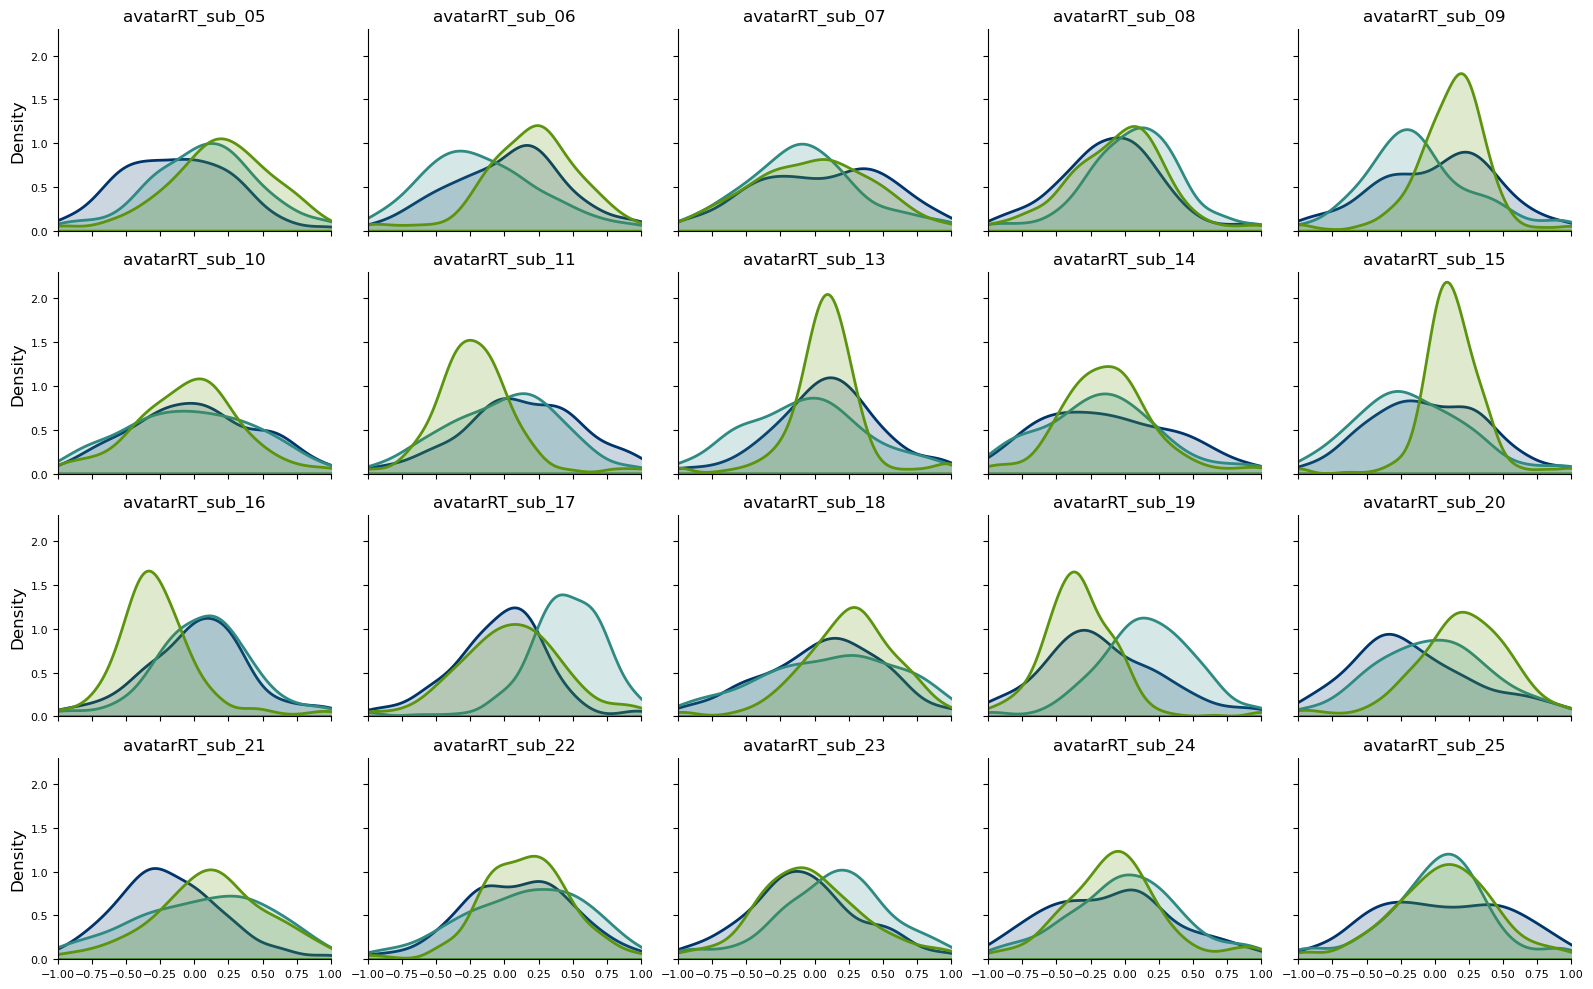

In [15]:
fig, axes = plt.subplots(4, 5, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

df = pd.DataFrame(columns = ['subject','nfb_component','projection_value'])

for i,sub in enumerate(SUB_IDS):
    x=np.load(f'{DATA_PATH}/{sub}/model/projected_test_runs.npy')
    im_comp = np.load(f'{DATA_PATH}/{sub}/model/manifold_pc_01.npy')
    wmp_comp = np.load(f'{DATA_PATH}/{sub}/model/manifold_pc_02.npy')
    omp_comp = np.load(f'{DATA_PATH}/{sub}/model/manifold_pc_20.npy')
    
    test_range_im = np.load(f'{DATA_PATH}/{sub}/model/test_range_01.npy') 
    test_range_wmp = np.load(f'{DATA_PATH}/{sub}/model/test_range_02.npy') 
    test_range_omp = np.load(f'{DATA_PATH}/{sub}/model/test_range_20.npy') 
    
    slope_im, int_im = np.polyfit(test_range_im, [-1, 1], 1)
    slope_wmp, int_wmp = np.polyfit(test_range_wmp, [-1, 1], 1)
    slope_omp, int_omp = np.polyfit(test_range_omp, [-1, 1], 1)

    
    im_proj = helper.map_projection(x, im_comp)
    wmp_proj = helper.map_projection(x, wmp_comp)
    omp_proj = helper.map_projection(x, omp_comp)
    
    MAP_ANGLE_IM = lambda x : slope_im * x + int_im
    MAP_ANGLE_WMP = lambda x : slope_wmp * x + int_wmp
    MAP_ANGLE_OMP = lambda x : slope_omp * x + int_omp
    
    im_mapped = np.clip(MAP_ANGLE_IM(im_proj), -1, 1)
    wmp_mapped = np.clip(MAP_ANGLE_WMP(wmp_proj), -1, 1)
    omp_mapped = np.clip(MAP_ANGLE_OMP(omp_proj), -1, 1)
    
    for c,p in zip(["IM","WMP",'OMP'], [im_mapped, wmp_mapped, omp_mapped]):
        df.loc[len(df)] = {'subject':sub, 'nfb_component':c, 'projection_value':p}
    
    sns.kdeplot(im_mapped, label='C_IM',alpha=0.2, fill=True, color=colors_main['IM'],ax=axes[i])
    sns.kdeplot(wmp_mapped, label='C_WM',alpha=0.2, fill=True, color=colors_main['WMP'],ax=axes[i])
    sns.kdeplot(omp_mapped, label='C_OM',alpha=0.2, fill=True, color=colors_main['OMP'],ax=axes[i])
    axes[i].set_title(f'{sub}')
    axes[i].set_xlim([-1, 1])    
    sns.despine()
df.to_csv('results/results_public/projections_on_components.csv')
fig.tight_layout()